# Summary Statistics and Exploration of Current State of Electricians

We're about to have a fun time trying to navigate this Excel file.

In [2]:
import pandas as pd
import numpy as np
from plotnine import *
import seaborn as sns
import statsmodels.api as sm
from great_tables import GT
import requests
from io import StringIO
import openpyxl as xl

In [3]:
df = pd.read_excel('../raw-data/OEWS_Electricians-05-24.xlsx', skiprows = 5)
df.head()

/Users/kevinphan981/Programming/electrician-policy/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default


,Area Name,Employment (1),Employment percent relative standard error (3),Hourly mean wage,Annual mean wage (2),Wage percent relative standard error (3),Hourly 10th percentile wage,Hourly 25th percentile wage,Hourly median wage,Hourly 75th percentile wage,Hourly 90th percentile wage,Annual 10th percentile wage (2),Annual 25th percentile wage (2),Annual median wage (2),Annual 75th percentile wage (2),Annual 90th percentile wage (2),"Employment per 1,000 jobs",Location Quotient
0,"Abilene, TX (00-10180)",460.0,6.4,24.62,51200.0,1.7,17.31,19.33,22.84,28.91,31.55,36010.0,40200.0,47500.0,60140.0,65620.0,6.240,1.30
1,"Aguadilla, PR (00-10380)",60.0,26.5,19.25,40040.0,10.4,10.38,11.85,16.26,25.04,29.21,21580.0,24650.0,33810.0,52080.0,60760.0,1.317,0.27
2,"Akron, OH (00-10420)",1430.0,3.6,36.00,74890.0,6.2,18.72,25.14,35.80,45.00,57.79,38940.0,52280.0,74470.0,93600.0,120190.0,4.480,0.93
3,Alaska nonmetropolitan area (02-00006),650.0,7.5,42.27,87910.0,2.0,24.50,29.66,40.58,50.01,61.25,50960.0,61680.0,84400.0,104010.0,127400.0,6.051,1.26
4,"Albany, GA (00-10500)",310.0,7.8,28.28,58820.0,2.4,17.36,22.26,28.39,36.69,37.45,36110.0,46310.0,59050.0,76310.0,77900.0,5.280,1.10


In [4]:
df.describe() #basic summary.
print(df.columns.values)

<StringArray>
[                                     'Area Name',
                                 'Employment (1)',
 'Employment percent relative standard error (3)',
                               'Hourly mean wage',
                           'Annual mean wage (2)',
       'Wage percent relative standard error (3)',
                    'Hourly 10th percentile wage',
                    'Hourly 25th percentile wage',
                             'Hourly median wage',
                    'Hourly 75th percentile wage',
                    'Hourly 90th percentile wage',
                'Annual 10th percentile wage (2)',
                'Annual 25th percentile wage (2)',
                         'Annual median wage (2)',
                'Annual 75th percentile wage (2)',
                'Annual 90th percentile wage (2)',
                      'Employment per 1,000 jobs',
                              'Location Quotient']
Length: 18, dtype: str


/Users/kevinphan981/Programming/electrician-policy/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


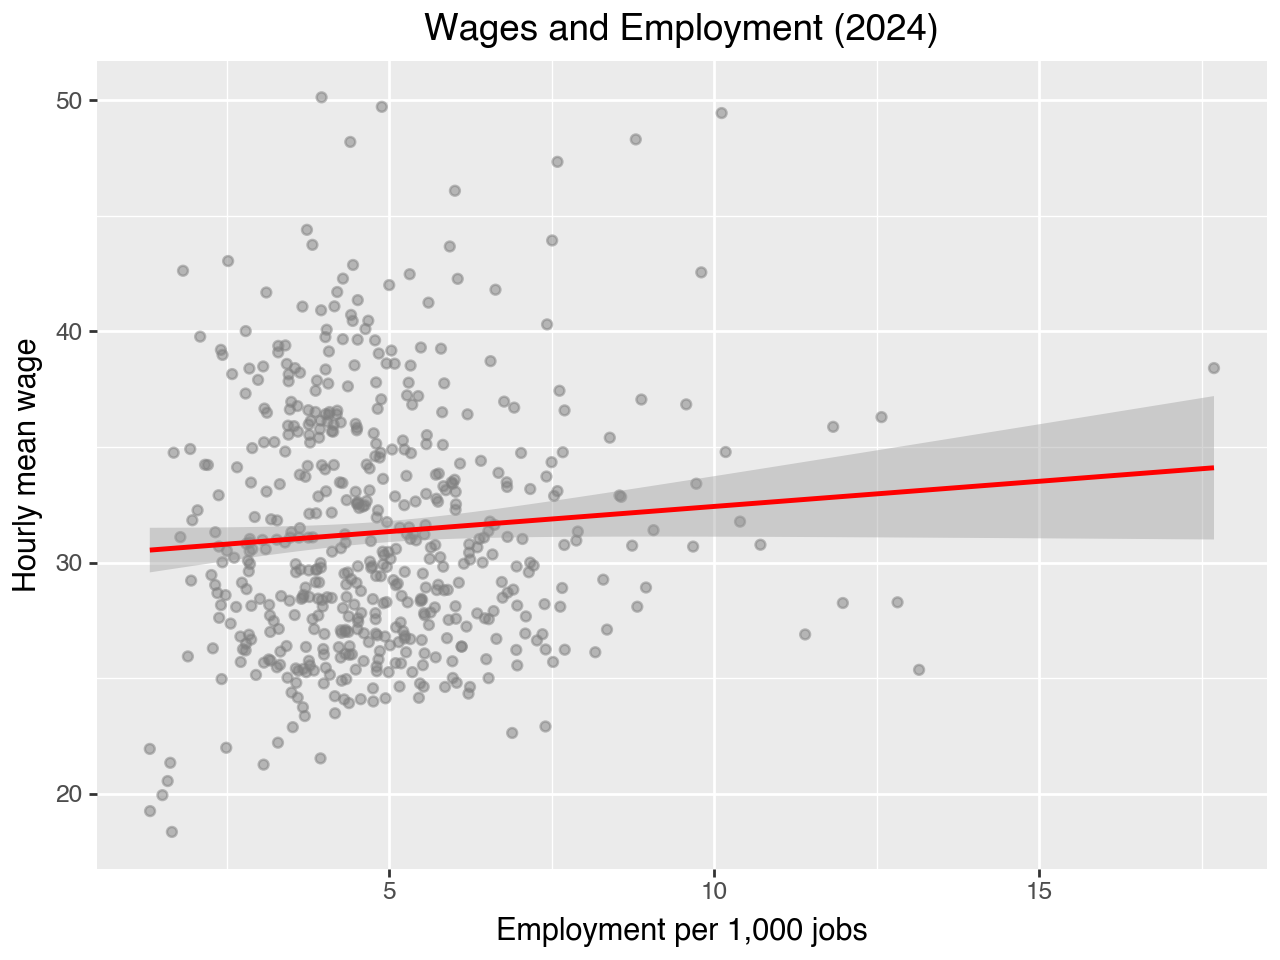

In [5]:
(
    ggplot(df, aes(x = "Employment per 1,000 jobs", y = "Hourly mean wage")) +
        geom_point(color = 'grey', alpha = .5) +
        geom_smooth(method = 'lm', color = 'red') + 
        labs(title = "Wages and Employment (2024)")
 )

/Users/kevinphan981/Programming/electrician-policy/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 8 rows containing non-finite values.


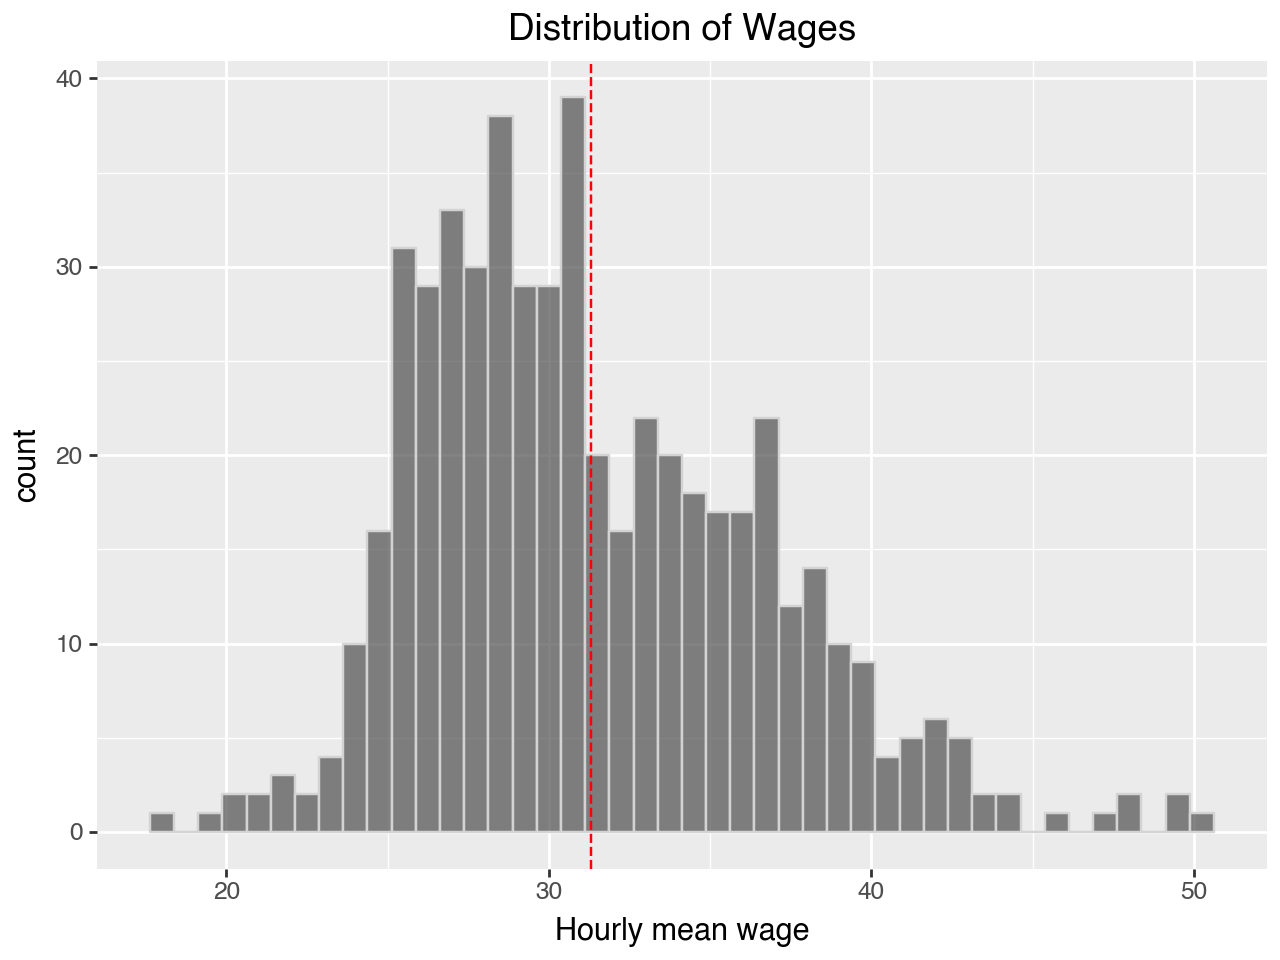

In [81]:
from plotnine import stat_summary

mean_wages = df["Hourly mean wage"].mean()
(
    ggplot(df, aes(x = "Hourly mean wage")) +
        geom_histogram(binwidth = .75, color = 'lightgrey', alpha = .75) + # alt argument is with bins
        labs(title = "Distribution of Wages") +
        geom_vline(xintercept = mean_wages, color = 'red', linetype = 'dashed')
)

# Filtering & Cleaning Operations

1. Needs to retrieve the county/state information from the data. Done through obtaining the IDs in parenthesis.
2. Preferably categorizes MSA and non-MSA data.


In [15]:
# obtaining and creating separate column for IDs
df["id"] = df["Area Name"].str.extract(r"\((.*?)\)")
df.head()

,Area Name,Employment (1),Employment percent relative standard error (3),Hourly mean wage,Annual mean wage (2),Wage percent relative standard error (3),Hourly 10th percentile wage,Hourly 25th percentile wage,Hourly median wage,Hourly 75th percentile wage,Hourly 90th percentile wage,Annual 10th percentile wage (2),Annual 25th percentile wage (2),Annual median wage (2),Annual 75th percentile wage (2),Annual 90th percentile wage (2),"Employment per 1,000 jobs",Location Quotient,id
0,"Abilene, TX (00-10180)",460.0,6.4,24.62,51200.0,1.7,17.31,19.33,22.84,28.91,31.55,36010.0,40200.0,47500.0,60140.0,65620.0,6.240,1.30,00-10180
1,"Aguadilla, PR (00-10380)",60.0,26.5,19.25,40040.0,10.4,10.38,11.85,16.26,25.04,29.21,21580.0,24650.0,33810.0,52080.0,60760.0,1.317,0.27,00-10380
2,"Akron, OH (00-10420)",1430.0,3.6,36.00,74890.0,6.2,18.72,25.14,35.80,45.00,57.79,38940.0,52280.0,74470.0,93600.0,120190.0,4.480,0.93,00-10420
3,Alaska nonmetropolitan area (02-00006),650.0,7.5,42.27,87910.0,2.0,24.50,29.66,40.58,50.01,61.25,50960.0,61680.0,84400.0,104010.0,127400.0,6.051,1.26,02-00006
4,"Albany, GA (00-10500)",310.0,7.8,28.28,58820.0,2.4,17.36,22.26,28.39,36.69,37.45,36110.0,46310.0,59050.0,76310.0,77900.0,5.280,1.10,00-10500
